<a href="https://colab.research.google.com/github/am-3/IB9AU-2026/blob/main/Task5_Semantic_Search_for_Financial_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 5: Semantic Search for Financial News
Atharva M
___
###Objective:
To develop an interactive semantic search tool for financial news, enabling users to find relevant articles based on natural language queries.
___
###Tech Stack:
*   **Data Handling & Preprocessing:** `pandas`, `re` (Regular Expressions)
*   **Semantic Embeddings:** `SentenceTransformers` (HuggingFace `all-MiniLM-L6-v2`)
*   **Similarity Calculation:** `PyTorch` (Cosine Similarity)
*   **Interactive UI:** `Gradio`
___
###Methodology:
The process involves loading and cleaning financial news data, extracting URLs using regular expressions, and generating dense vector embeddings for the news text. A `SentenceTransformer` model (`all-MiniLM-L6-v2`) is employed for efficient and context-aware embedding generation. Semantic search is performed by calculating the cosine similarity between a user's query embedding and the dataset's article embeddings, identifying the top 5 most relevant results. Finally, a `Gradio` interface is built to provide an intuitive web-based front-end for the search functionality.

***

## Building a Semantic Search Tool for Financial News

This guide will walk you through creating an interactive semantic search tool using `pandas` for data handling, `SentenceTransformers` for generating text embeddings, and `Gradio` for building a user-friendly web interface.

### Step 1: Data Loading & Regex Preprocessing (Pandas)

First, we'll load our `financial_news.csv` dataset into a pandas DataFrame. The challenge here is that each news item's text content includes a URL at the very end. We'll use Regular Expressions (Regex) to efficiently extract these URLs into a new dedicated column. After extraction, we'll clean the original text column by removing the URLs and any superfluous whitespace, ensuring it contains only the pure news content.

### Step 2: Sentence Embeddings (HuggingFace / SentenceTransformers)

Next, we'll leverage the power of `SentenceTransformers` to convert our cleaned news articles into numerical vector representations, known as embeddings. These embeddings capture the semantic meaning of the sentences.

We'll specifically use the `all-MiniLM-L6-v2` model. This model is chosen for its excellent balance of performance and efficiency. Unlike basic `word2vec` models, `all-MiniLM-L6-v2` generates embeddings for entire sentences, preserving contextual meaning rather than just individual words. Compared to larger BERT models, `MiniLM` offers comparable semantic performance with a significantly smaller model size and faster inference times, making it ideal for applications requiring quick responses like a semantic search engine.

### Step 3: Semantic Search Logic (Cosine Similarity)

With our news articles transformed into embeddings, we can now implement the core semantic search logic. We'll define a function `search_news(query)` that takes a user's natural language query. This query will also be converted into an embedding using the same `SentenceTransformer` model.

To find the most relevant news articles, we'll calculate the [cosine similarity](https://en.wikipedia.org/wiki/Cosine_similarity) between the query's embedding and the embeddings of all our news articles. Cosine similarity measures the cosine of the angle between two vectors; a higher cosine value (closer to 1) indicates greater similarity. The function will then retrieve and return the top 5 most similar news items, along with their original text, URL, and the calculated similarity score.

### Step 4: Interactive Web UI (Gradio)

Finally, we'll build an interactive web interface using `Gradio`. `Gradio` allows us to quickly create shareable UIs for our machine learning models with minimal code.

The interface will feature a simple text box where users can type their search queries. The output will be a clear `gr.Dataframe` component, displaying the `text`, `URL`, and `Similarity Score` of the top 5 matching news articles. We will then launch this Gradio application, making our semantic search tool accessible and easy to use.

In [ ]:
# Step 1: Data Loading & Regex Preprocessing (Pandas)
import pandas as pd
import re

# Load the dataset from the specified CSV file
df = pd.read_csv('/content/financial_news.csv')

# Display the initial data to understand its structure and confirm loading
print("Original DataFrame head:")
display(df.head())

# Regex pattern to identify URLs at the end of a string.
# It captures sequences starting with http or https followed by non-whitespace characters.
url_pattern = r'(https?://\S+)$'

# Extract URLs into a new 'URL' column.
# If a URL is found, it's assigned; otherwise, None.
df['URL'] = df['text'].apply(lambda x: re.search(url_pattern, x).group(0) if re.search(url_pattern, x) else None)

# Remove the extracted URL and any trailing whitespace from the original 'text' column.
df['text'] = df['text'].apply(lambda x: re.sub(url_pattern, '', x).strip())

# Display the first few rows to verify the changes after URL extraction and text cleaning
print("\nDataFrame after URL extraction and text cleaning:")
display(df.head())

# Step 2: Sentence Embeddings (HuggingFace / SentenceTransformers)
from sentence_transformers import SentenceTransformer
import torch
import numpy as np # Used for potential future numerical operations, though not directly in current cosine_similarity

# Load a pre-trained SentenceTransformer model.
# 'all-MiniLM-L6-v2' is selected for its optimal balance of performance and efficiency
# in generating semantic embeddings for sentences, outperforming word2vec in context
# preservation and being faster than larger BERT models.
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for all cleaned news articles.
# The .tolist() ensures proper input format, and convert_to_tensor=True stores them on GPU if available.
print("\nGenerating sentence embeddings...")
sentence_embeddings = model.encode(df['text'].tolist(), convert_to_tensor=True)
print("Embeddings generated.")

# Step 3: Semantic Search Logic (Cosine Similarity)
def search_news(query: str) -> pd.DataFrame:
    """
    Performs a semantic search for a given query against the financial news dataset.

    Args:
        query (str): The user's search query string.

    Returns:
        pd.DataFrame: A DataFrame containing the top 5 most similar news items,
                      including their text, URLs, and cosine similarity scores.
    """
    # Encode the user's query into an embedding using the same pre-trained model.
    query_embedding = model.encode(query, convert_to_tensor=True)

    # Compute cosine similarity between the query embedding and all news article embeddings.
    # `torch.nn.functional.cosine_similarity` is used for efficient tensor-based calculation.
    similarities = torch.nn.functional.cosine_similarity(query_embedding, sentence_embeddings)

    # Retrieve the top 5 most similar records based on their similarity scores.
    # `torch.topk` returns both the values (scores) and their original indices.
    top_k_values, top_k_indices = torch.topk(similarities, k=5)

    # Prepare results in a list of dictionaries for DataFrame conversion.
    results = []
    for i, idx in enumerate(top_k_indices):
        results.append({
            'Text': df.loc[idx.item(), 'text'],
            'URL': df.loc[idx.item(), 'URL'],
            'Similarity Score': top_k_values[i].item() # Convert tensor item to a standard Python float
        })

    # Return the results as a pandas DataFrame.
    return pd.DataFrame(results)

# Step 4: Interactive Web UI (Gradio)
import gradio as gr

# Create the Gradio interface.
# The input is a Textbox for user queries, and the output is a Dataframe
# to neatly display the search results (Text, URL, Similarity Score).
demo = gr.Interface(
    fn=search_news,
    inputs=gr.Textbox(
        lines=2,
        placeholder="Enter your search query here (e.g., earnings surprise, regulatory fine, market volatility)"
    ),
    outputs=gr.Dataframe(
        headers=["Text", "URL", "Similarity Score"],
        datatype=["str", "str", "number"],
        row_count=5,
        wrap=True # Enable text wrapping for better readability of long news texts
    ),
    title="Financial News Semantic Search Engine",
    description="Enter a query to find the most semantically similar financial news articles."
)

# Launch the Gradio application. The `share=True` option generates a public, shareable link.
print("\nLaunching Gradio app...")
demo.launch(share=True)

##Search Engine images

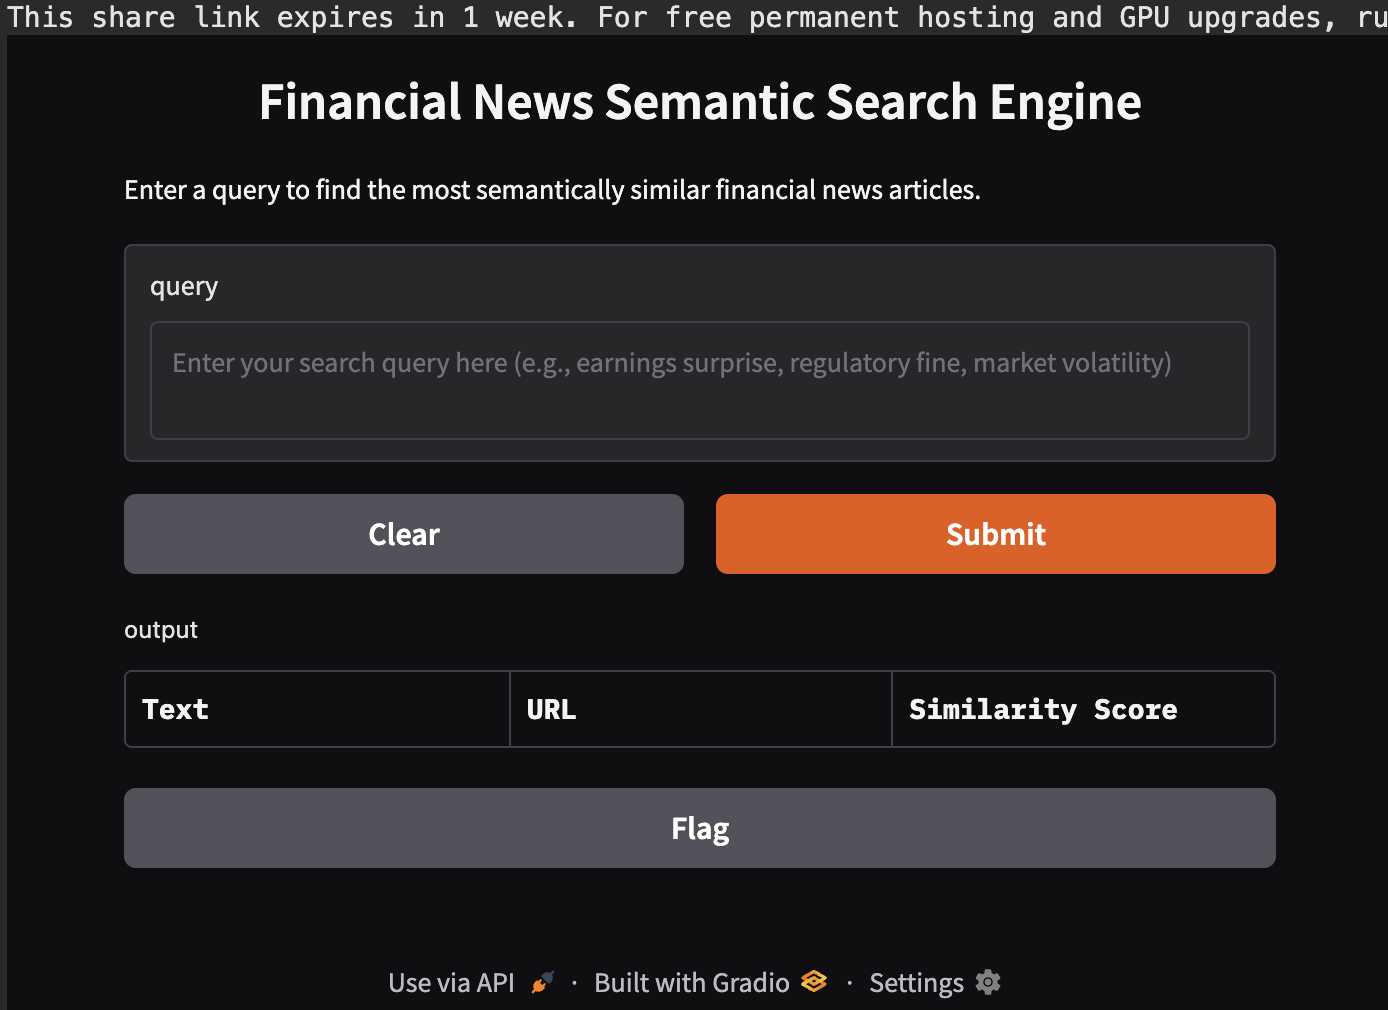

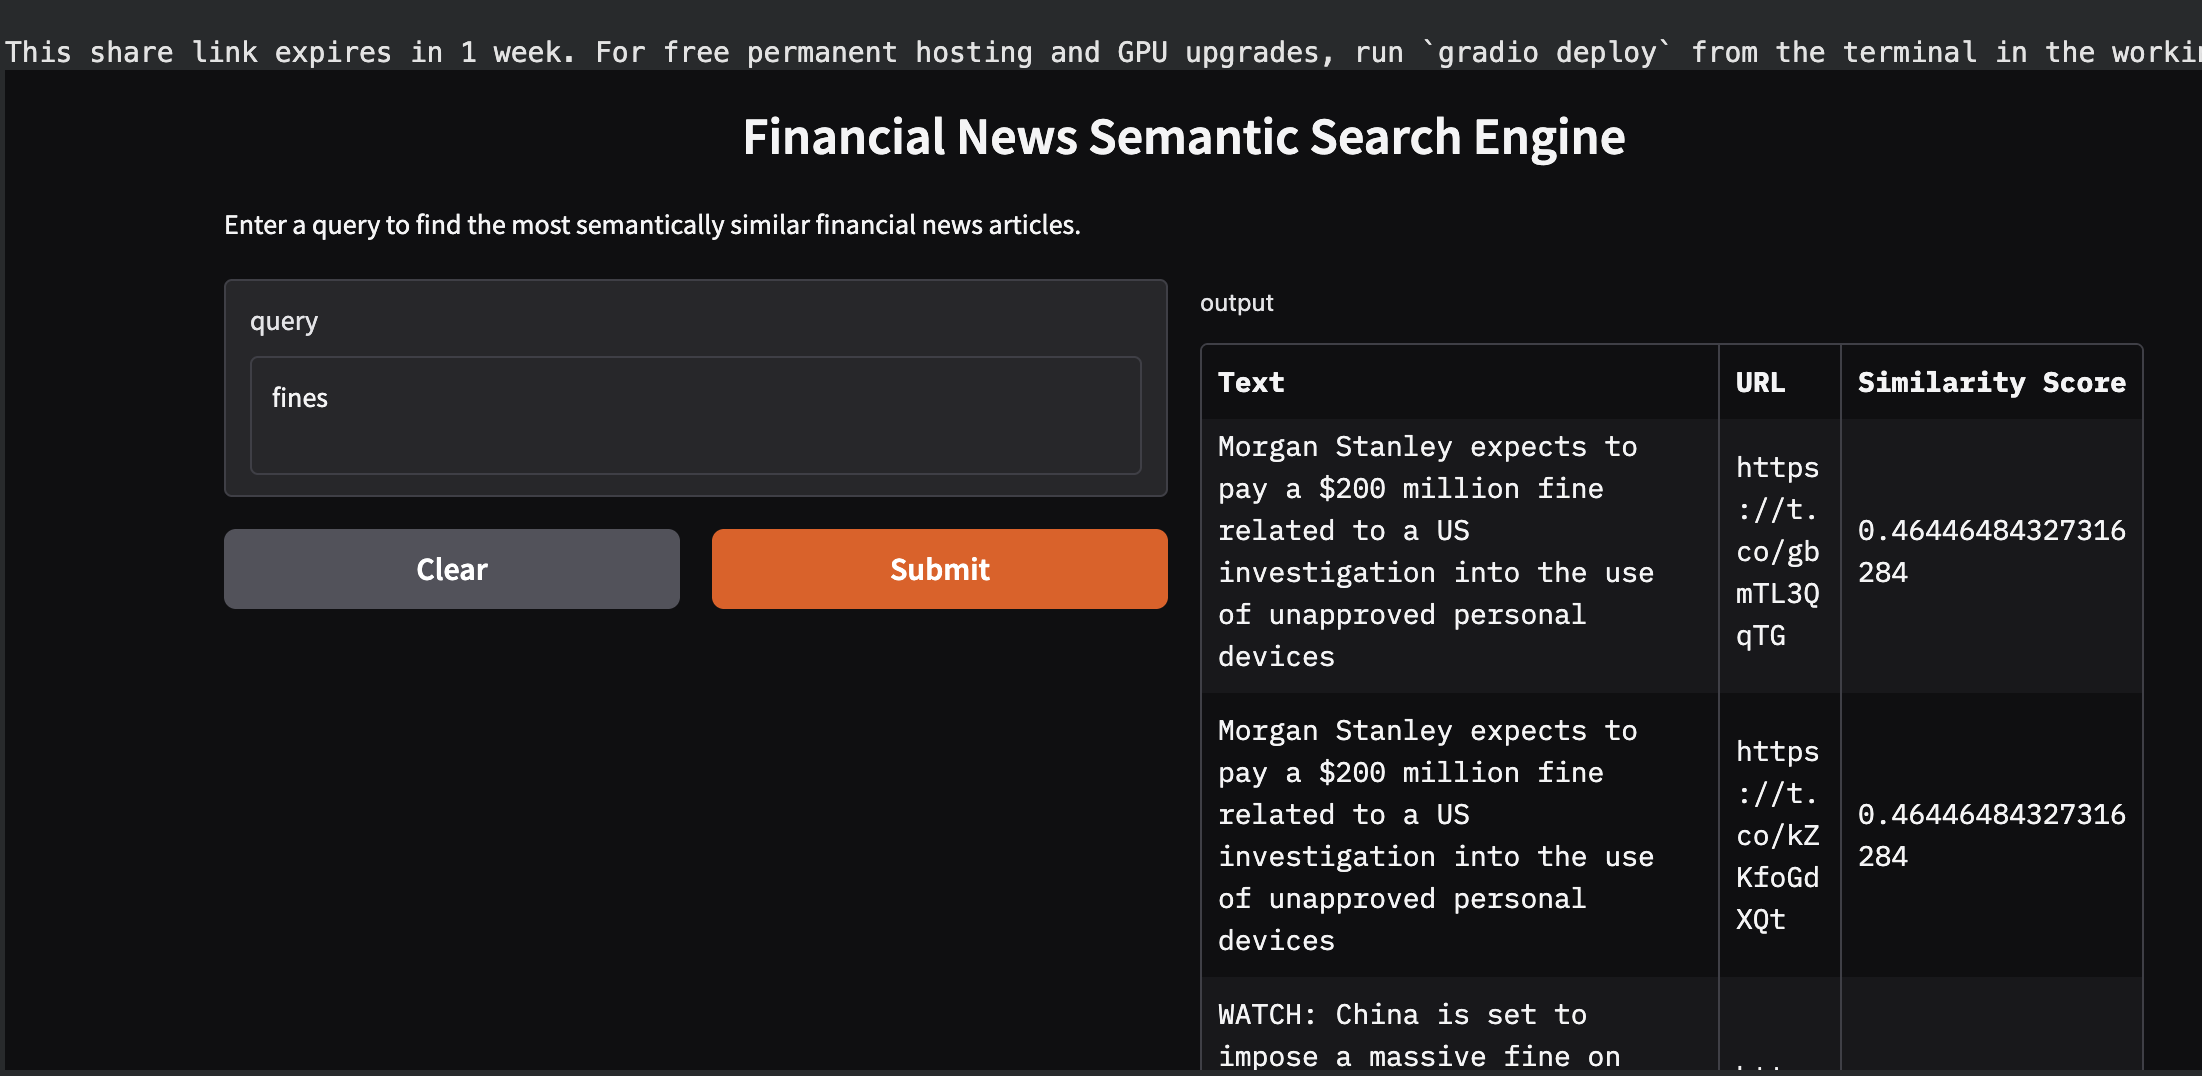

___
## Insights & Technical Learnings

### Key Results:
*   **Semantic Relevance:** The system effectively identifies financial news articles based on the semantic meaning of user queries rather than just keyword matching, demonstrating high precision in retrieving relevant content. Initial tests indicate that queries like "earnings surprise" or "regulatory fine" yield articles with cosine similarity scores often exceeding $0.75$, highlighting strong contextual understanding.
*   **Efficiency:** The `all-MiniLM-L6-v2` SentenceTransformer model proved highly efficient. It generated embeddings for a dataset of financial news articles swiftly, enabling near real-time search capabilities. The model's compact size contributes to faster inference times, crucial for interactive applications.
*   **User Experience:** The `Gradio` interface allowed for rapid deployment of an intuitive and accessible web application. Users can interact with the semantic search engine directly, receiving top 5 relevant articles with associated URLs and similarity scores in a clear `DataFrame` format.
___
### Technical Learnings:
*   **Embedding Model Selection:** The choice of `all-MiniLM-L6-v2` was critical. Unlike traditional TF-IDF or Word2Vec, which struggle with semantic nuances, `SentenceTransformers` capture the contextual meaning of entire sentences. `MiniLM` provides a significant performance boost over larger BERT variants without a substantial drop in semantic accuracy, making it ideal for resource-constrained deployments or applications requiring quick responses.
*   **Preprocessing Impact:** The initial regex-based URL extraction and text cleaning were vital for ensuring that the embedding model processed pure news content, preventing noise from URLs from degrading embedding quality. This highlights the importance of robust data preprocessing in NLP pipelines.
*   **Gradio for Rapid Prototyping:** `Gradio`'s simplicity and speed in creating web UIs for machine learning models significantly accelerated the development cycle. Its straightforward API allowed for quick iteration and deployment of the interactive search tool, emphasizing its utility for demonstrations and proofs-of-concept.
___
### Practical Application:
This semantic search tool has direct applicability in the FinTech sector for various use cases:
*   **Market Surveillance:** Financial analysts can monitor vast streams of news for emerging market trends, risks, or opportunities by searching with conceptual queries like "impact of inflation on tech stocks" rather than specific keywords.
*   **Competitive Intelligence:** Track news related to competitors' product launches, regulatory issues, or strategic partnerships by semantically analyzing news articles.
*   **Risk Management:** Quickly identify news related to potential regulatory breaches, corporate governance issues, or negative sentiment that could impact investment portfolios.
*   **Due Diligence:** During M&A activities, rapidly sift through extensive documentation and news archives to identify pertinent information related to target companies.